In [ ]:
!pip install -q pandas scikit-learn matplotlib seaborn optuna huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 9.8 MB/s eta 0:00:00


In [ ]:
import os
import re
import pickle
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [ ]:
DATA_PATH = "data/emails.csv"

CATEGORIES = ["forum", "promotions", "social_media", "spam", "updates", "verify_code", "oportunities", "finance", "college"]
PRIORITIES = ["high", "medium", "low"]

In [ ]:
MAX_LEN = 200
EMBED_DIM = 128
HIDDEN_DIM = 128
NUM_LAYERS = 1
DROPOUT = 0.3
BATCH_SIZE = 32
LR = 1e-3
EPOCHS = 20
MIN_WORD_FREQ = 2

REAL_OVERSAMPLE_FACTOR = 8
SPARSE_REAL_CATEGORIES = {"oportunities", "finance", "college"}

In [ ]:
ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
from huggingface_hub import hf_hub_download

REPO_ID = "jason23322/high-accuracy-email-classifier"

train_path = hf_hub_download(repo_id=REPO_ID, filename="train.csv", repo_type="dataset")
test_path = hf_hub_download(repo_id=REPO_ID, filename="test.csv", repo_type="dataset")

hf_train_df = pd.read_csv(train_path)
hf_test_df = pd.read_csv(test_path)

print("train rows:", len(hf_train_df), "| test rows:", len(hf_test_df))
hf_train_df.head()

train.csv:   0%|          | 0.00/3.01M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/769k [00:00<?, ?B/s]

train rows: 10780 | test rows: 2697


,id,subject,body,text,category,category_id
0,promotions_582,Anniversary Special: Buy one get one free,"As our loyal customer, get exclusive $60 off $...",Anniversary Special: Buy one get one free As o...,promotions,1
1,spam_1629,Your Amazon was used on new device,Your $5000 refund is processed. Claim: bit.ly/...,Your Amazon was used on new device Your $5000 ...,spam,3
2,spam_322,Re: Your Google inquiry,"Hi, following up about your Google application...","Re: Your Google inquiry Hi, following up about...",spam,3
3,social_media_80,Digital Ritual Experience Creation,Cross-cultural ceremony design. Join: virtualr...,Digital Ritual Experience Creation Cross-cultu...,social_media,2
4,forum_1351,"Your post was moved to ""Programming Help""","Trending: ""cooking"" (258 comments). View: supp...","Your post was moved to ""Programming Help"" Tren...",forum,0


In [ ]:
CATEGORY_TO_PRIORITY = {
    "verify_code": "high",
    "updates": "medium",
    "forum": "medium",
    "spam": "low",
    "promotions": "medium",
    "social_media": "low",
    "oportunities": "high",
    "finance": "high",
    "college": "medium",
}
URGENT_KEYWORDS = ["urgent", "asap", "expire", "immediately", "deadline", "fast" , "quick" , "soon"]

def assign_priority(row):
    base = CATEGORY_TO_PRIORITY.get(row["category"], "medium")
    if row["category"] == "spam":
        return base
    text = f"{row['subject']} {row['body']}".lower()
    if any(k in text for k in URGENT_KEYWORDS):
        return "high"
    return base


In [ ]:
hf_full_df = pd.concat([hf_train_df, hf_test_df], ignore_index=True)
hf_full_df["priority"] = hf_full_df.apply(assign_priority, axis=1)

In [ ]:

final_df = hf_full_df[["subject", "body", "category", "priority"]].dropna()

os.makedirs("data", exist_ok=True)
final_df.to_csv(DATA_PATH, index=False)

print("Saved", len(final_df), "rows to", DATA_PATH)
print(final_df["category"].value_counts())
print(final_df["priority"].value_counts())

Saved 13477 rows to data/emails.csv
category
verify_code     2251
forum           2250
social_media    2245
promotions      2245
spam            2243
updates         2243
Name: count, dtype: int64
priority
medium    6071
low       4480
high      2926
Name: count, dtype: int64


In [ ]:
import random
import pandas as pd

random.seed(SEED)

TARGET_PER_CATEGORY = 2000

SPARSE_TARGET_PER_CATEGORY = 400


TOPICS = ["cooking","python programming","home renovation","fitness","travel tips","budget gaming pcs",
          "photography","gardening","cryptocurrency","movie reviews","job hunting","language learning",
          "car maintenance","vegan recipes","startups","personal finance","board games","hiking",
          "digital art","freelancing","interior design","running","yoga","machine learning","music production",
          "book clubs","parenting","woodworking","cybersecurity","urban gardening","deployment","development"]
NAME_PARTS = ["alex","maria","dev","sunny","kpop","coder","traveler","bookworm","chef","runner","nova",
              "pixel","luna","max","zara","kai","ravi","noor","theo","ivy","sam","jordan","priya","liam",
              "mia","arjun","ella","tom","sofia","leo","student","teacher","hr","salesman","seller"]
PRODUCTS = ["wireless earbuds","running shoes","a laptop stand","a coffee maker","a yoga mat","a smartwatch",
            "noise-cancelling headphones","a backpack","a desk lamp","an air fryer","a blender","a tablet",
            "a fitness tracker","a bluetooth speaker","a water bottle","sunglasses","a phone case",
            "a gaming mouse","a webcam","an electric kettle"]
BRANDS = ["Zentra","Nuvex","Blomm","Kavo","Pixelow","Trendify","Urbanica","Glowe","Vantix","Merido",
          "Solace","Brightly","Cascade","Lumino","Fernway"]
PLACES = ["Downtown Cafe","Riverside Park","The Grand Hotel","Sunset Beach","City Mall","Old Town Square",
          "Lakeview Trail","Central Station","Harbor View","Maple Street Diner","Union Square","North Gate Plaza",
          "Willow Creek","The Rooftop Bar","Museum District"]
PLATFORMS = ["Instagram","Facebook","Twitter","LinkedIn","TikTok","Snapchat","Pinterest","Threads","Unstop","Render","Medium","Kaggle"]
DEVICES = ["a new iPhone","an Android device","a Windows laptop","an unrecognized device","a Chromebook",
           "a MacBook","an iPad","a Samsung tablet","a Linux workstation","an unknown browser"]
SERVICES = ["Netflix","Spotify","your bank account","your cloud storage","your email account",
            "your streaming subscription","your fitness app","PayPal","your ride-sharing app",
            "your food delivery account","your gaming account","your VPN service","your calendar app",
            "your photo backup service","your online store account","your website"]
PRIZES = ["iPhone 16","$1000 Amazon gift card","PS5","MacBook Pro","free vacation","Nintendo Switch",
          "$500 Visa gift card","AirPods Pro","smart TV","free cruise","gaming laptop","$2000 cash prize"]

def uname(): return f"{random.choice(NAME_PARTS)}{random.randint(1, 9999)}"
def rnd_code(): return str(random.randint(100000, 999999))
def rnd_amount(): return f"${random.randint(20, 9999)}"
def rnd_pct(): return str(random.randint(5, 75))
def rnd_count(): return str(random.randint(2, 95))
def rnd_year(): return str(random.randint(2017, 2026))
def rnd_date(): return f"{random.choice(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])}, {random.choice(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])} {random.randint(1,28)}"
def rnd_mins(): return str(random.randint(3, 45))
def rnd_hrs(): return str(random.randint(1, 72))

GREETINGS = ["Hi {name},", "Hello,", "Dear Customer,", "Hey there,", "Dear {name},", "Hi there,"]
SIGNOFFS = ["Best regards,\n{brand} Team", "Thanks,\nThe {brand} Team", "Sent from my iPhone",
            "This is an automated message, please do not reply.", "Unsubscribe | Privacy Policy | Help Center",
            "Cheers,\n{brand} Support", "You are receiving this email because you have an account with {brand}."]
FWD_HEADER = "---------- Forwarded message ---------\nFrom: {sender}\nDate: {date}\nSubject: {subj}\n\n"

def maybe_typo(text):
    words = text.split()
    if len(words) > 4 and random.random() < 0.12:
        i = random.randrange(len(words))
        w = words[i]
        if len(w) > 3:
            j = random.randrange(len(w) - 1)
            w = w[:j] + w[j+1] + w[j] + w[j+2:]
            words[i] = w
    return " ".join(words)

def add_realism_noise(subject, body):
    name = random.choice(NAME_PARTS).title()
    brand = random.choice(BRANDS)
    if random.random() < 0.30:
        body = f"{random.choice(GREETINGS).format(name=name)}\n\n{body}"
    if random.random() < 0.30:
        body = f"{body}\n\n{random.choice(SIGNOFFS).format(brand=brand)}"
    if random.random() < 0.10:
        body = FWD_HEADER.format(sender=f"{uname()}@example.com", date=rnd_date(), subj=subject) + body
    if random.random() < 0.10:
        subject = subject.upper()
    elif random.random() < 0.10:
        subject = subject.lower()
    body = maybe_typo(body)
    return subject, body

def gen_forum():
    topic, user, brand = random.choice(TOPICS), uname(), random.choice(BRANDS)
    kind = random.choice(["moved","reply","trending","mention","digest","milestone","complete"])
    if kind == "moved":
        return (f"Your post about {topic} was moved",
                 f"Your post about {topic} was moved to a new board by a moderator ({user}). View the thread to see replies.")
    if kind == "reply":
        return (f"{user} replied to your post on {topic}",
                 f"{user} replied to your post about {topic}. Click here to view the full discussion thread.")
    if kind == "trending":
        return (f"Trending in {topic}: {rnd_count()} comments",
                 f"A thread about {topic} started by {user} is trending with {rnd_count()} comments. View the discussion before it closes.")
    if kind == "mention":
        return (f"{user} mentioned you in a {topic} thread",
                 f"{user} mentioned you in a discussion about {topic}. Tap to see the full context and reply.")
    if kind == "milestone":
        return (f"Your {topic} post hit {rnd_count()} upvotes",
                 f"Congrats — your post about {topic} reached {rnd_count()} upvotes and is now featured by {brand} Forums.")
    if kind == "complete":
        return (f"{user} replied to your resume {topic}",
                 f"{user} replied to your resume about {topic}. Click here to view the full conversation.")
    return (f"Weekly digest: top {topic} discussions",
             f"Here are this week's top discussions about {topic} curated for you, including a thread from {user}.")

def gen_promotions():
    product, brand, place = random.choice(PRODUCTS), random.choice(BRANDS), random.choice(PLACES)
    p = rnd_pct()
    kind = random.choice(["sale","cart","rewards","flash","newsletter","referral","opportunity"])
    if kind == "sale":
        return (f"{p}% off {product} this weekend — {brand}",
                 f"Shop now and save {p}% on {product} from {brand}. Limited time offer, ends Sunday.")
    if kind == "cart":
        return (f"You left {product} in your cart",
                 f"You left {product} in your {brand} cart. Complete your order now and get {p}% off with code SAVE{p}.")
    if kind == "rewards":
        return (f"{brand} Rewards: {rnd_count()} points waiting",
                 f"You have {rnd_count()} {brand} Rewards points. Redeem them for {product} before they expire this month.")
    if kind == "flash":
        return (f"Flash sale: {product} at {brand}",
                 f"Today only — {product} is on sale for {p}% off at {brand}. Grab yours before the flash sale ends.")
    if kind == "referral":
        return (f"Refer a friend, get {p}% off at {brand}",
                 f"Invite a friend to {brand} and you'll both get {p}% off your next order of {product}.")
    if kind == "opportunity":
        return (f"A special {p}% off opportunity at {brand}",
                 f"Invite a friend to join this deal at {brand} and you'll both get {p}% off your next order of {product}.")
    return (f"{brand} newsletter: new arrivals near {place}",
             f"Check out new arrivals at {brand}, including {product}, now available near {place}.")

def gen_social_media():
    user, platform, place = uname(), random.choice(PLATFORMS), random.choice(PLACES)
    kind = random.choice(["checkin","like","notif","memory","tag","follow"])
    if kind == "checkin":
        return (f"{rnd_count()} friends checked in at \"{place}\"",
                 f"{rnd_count()} friends checked in at \"{place}\" on {platform}. See photos and updates from the visit.")
    if kind == "like":
        return (f"{user} liked your photo",
                 f"{user} and {rnd_count()} others liked your recent photo on {platform}. See who else reacted.")
    if kind == "notif":
        return (f"You have {rnd_count()} new notifications on {platform}",
                 f"You have {rnd_count()} unread notifications on {platform}, including likes, comments, and follows from {user}.")
    if kind == "tag":
        return (f"{user} tagged you in a photo",
                 f"{user} tagged you in a photo taken at {place}. View it on {platform} now.")
    if kind == "follow":
        return (f"{user} started following you on {platform}",
                 f"{user} started following you on {platform}. Check out their profile and follow back.")
    return (f"Memories from this week in {rnd_year()}",
             f"See your memories from this week in {rnd_year()}, including photos from {place} on {platform}.")

def gen_spam():
    prize, service = random.choice(PRIZES), random.choice(SERVICES)
    amt, h = rnd_amount(), rnd_hrs()
    kind = random.choice(["prize","hold","suspend","claim","lottery","inheritance"])
    if kind == "prize":
        return (f"Congratulations! You've won a {prize}!",
                 f"Congratulations! You've won a {prize}! Click here immediately to claim your prize now. Limited time offer expires in {h} hours.")
    if kind == "hold":
        return (f"{amt} held for verification",
                 f"{amt} held for verification on {service}. Confirm your account details immediately or funds will be forfeited within {h} hours.")
    if kind == "suspend":
        return (f"URGENT: {service} will be suspended",
                 f"{service} will be suspended within {h} hours unless you verify your identity immediately. Act now to avoid losing access.")
    if kind == "lottery":
        return (f"You've been selected to win {amt}",
                 f"You've been randomly selected to win {amt} in our sweepstakes. Reply immediately with your details to claim.")
    if kind == "inheritance":
        return ("Urgent: unclaimed funds notice",
                 f"An unclaimed inheritance of {amt} is waiting for you. Contact us immediately before the deadline in {h} hours.")
    return (f"Claim your free {prize} now!!!",
             f"You have been selected to receive a free {prize}. Claim now before this offer expires in {h} hours.")

def gen_updates():
    service, device = random.choice(SERVICES), random.choice(DEVICES)
    kind = random.choice(["security","maintenance","renewal","terms","password","billing","done","added"])
    if kind == "security":
        return (f"Security alert: new sign-in to {service}",
                 f"We noticed a new sign-in to {service} from {device} on {rnd_date()}. If this wasn't you, secure your account.")
    if kind == "maintenance":
        return (f"{service}: scheduled maintenance on {rnd_date()}",
                 f"{service} will undergo scheduled maintenance on {rnd_date()}. Some features may be unavailable during this time.")
    if kind == "renewal":
        return (f"Your {service} subscription has been renewed",
                 f"Your subscription to {service} has been renewed. Your next billing date is {rnd_date()}.")
    if kind == "password":
        return (f"Your {service} password was changed",
                 f"Your password for {service} was changed on {rnd_date()} from {device}. Contact support if this wasn't you.")
    if kind == "billing":
        return (f"{service}: your receipt for this month",
                 f"Your payment for {service} was processed on {rnd_date()}. View your receipt for details.")
    if kind == "done":
        return (f"{service}: your task is complete",
                 f"Your task on {service} was processed on {rnd_date()}. View your updates for details.")
    if kind == "added":
        return (f"{service}: a new item was added",
                 f"A new item was added to {service} and processed on {rnd_date()}. View your updates for details.")
    return (f"Important update to {service}'s Terms of Service",
             f"We've updated our Terms of Service for {service}, effective {rnd_date()}. Please review the changes.")

def gen_verify_code():
    service = random.choice(SERVICES)
    c, m = rnd_code(), rnd_mins()
    kind = random.choice(["otp","twostep","login","reset","signup","verify"])
    if kind == "otp":
        return (f"Your {service} verification code",
                 f"Your one-time verification code for {service} is {c}. This code will expire in {m} minutes. Do not share this code with anyone.")
    if kind == "twostep":
        return (f"Two-step verification code: {c}",
                 f"Two-step verification code: {c}. Enter this code to complete your login to {service}. Do not share it with anyone.")
    if kind == "reset":
        return (f"Password reset code for {service}",
                 f"Use code {c} to reset your {service} password. This code expires in {m} minutes.")
    if kind == "signup":
        return (f"Confirm your {service} sign-up",
                 f"Welcome! Use code {c} to confirm your new {service} account. It expires in {m} minutes.")
    if kind == "verify":
        return (f"Confirm your {service} verification code",
                 f"Use this code {c} to confirm your new {service} account. It expires in {m} minutes.")
    return (f"Use code {c} to complete your login",
             f"Use verification code {c} to finish signing in to {service}. It expires in {m} minutes.")

def gen_oportunities():
    topic, user, product = random.choice(TOPICS), uname(), random.choice(PRODUCTS)
    kind = random.choice(["job", "investment", "project", "collaboration", "grant", "award", "hackathon", "internship"])
    if kind == "job":
        return (f"New job opportunity: {topic}",
                f"We found a new job opportunity for you in {topic}. Apply now to be considered.")
    if kind == "hackathon":
        event = random.choice(["Smart India Hackathon", "HackTheNorth", "CodeStorm", f"{topic.title()} Hackathon", "DevSprint"])
        return (f"You're invited: {event} {rnd_year()}",
                f"Registrations for {event} {rnd_year()} are now open. Team up and build something around {topic}. Deadline to register: {rnd_date()}.")
    if kind == "internship":
        return (f"Your internship application at {random.choice(BRANDS)} has been shortlisted",
                f"Congratulations {user}, your application for the {topic} internship has been shortlisted. Next round details will follow shortly.")
    if kind == "investment":
        return (f"Exclusive investment opportunity in {topic}",
                f"Don't miss out on this exclusive investment opportunity in {topic} with potential returns of {rnd_pct()}%.")
    if kind == "project":
        return (f"Project collaboration request: {topic}",
                f"{user} is looking for collaborators on a new {topic} project. Learn more and join.")
    if kind == "collaboration":
        return (f"Collaboration offer for your {topic} work",
                f"{user} is impressed with your work in {topic} and wants to collaborate on a new venture.")
    if kind == "grant":
        return (f"Grant opportunity for {topic} research",
                f"A new grant program is open for {topic} research. Apply by {rnd_date()} to secure funding.")
    return (f"You've been nominated for a {topic} award!",
            f"Congratulations! You've been nominated for the {topic} award. Click to accept and see details.")

def gen_finance():
    service, brand = random.choice(SERVICES), random.choice(BRANDS)
    amt, acct = rnd_amount(), random.randint(1000, 9999)
    kind = random.choice(["debit", "credit_upi", "card_bill", "salary", "low_balance", "refund", "sip"])
    if kind == "debit":
        return (f"Rs.{amt.strip('$')} debited from your A/c",
                 f"Dear Customer, your account XX{acct} has been debited by Rs.{amt.strip('$')} on {rnd_date()}. Available balance: Rs.{rnd_amount().strip('$')}. If this wasn't you, report immediately.")
    if kind == "credit_upi":
        return (f"Payment of Rs.{amt.strip('$')} successful",
                 f"Your UPI payment of Rs.{amt.strip('$')} has been completed successfully. Transaction ID: {rnd_code()}.")
    if kind == "card_bill":
        return (f"{brand} Credit Card statement is generated",
                 f"Your credit card statement for the billing cycle ending {rnd_date()} is now available. Total amount due: Rs.{amt.strip('$')}. Payment due date: {rnd_date()}.")
    if kind == "salary":
        return ("Salary credited to your account",
                 f"Your salary amounting to Rs.{amt.strip('$')} has been credited to your registered bank account on {rnd_date()}.")
    if kind == "low_balance":
        return ("Low balance alert",
                 f"Your available balance in A/c XX{acct} is Rs.{rnd_amount().strip('$')}, which is below the minimum required balance.")
    if kind == "refund":
        return (f"Refund of Rs.{amt.strip('$')} credited",
                 f"Your refund has been processed. Rs.{amt.strip('$')} will be credited to your original payment method within 5-7 business days.")
    return ("Your SIP installment has been processed",
             f"Your monthly SIP installment of Rs.{amt.strip('$')} has been processed successfully. Units allotted at current NAV.")

def gen_college():
    course, user = random.choice(TOPICS), uname()
    kind = random.choice(["deadline_ext","exam_sched","fee","advisor","result","reschedule","placement"])
    if kind == "deadline_ext":
        return (f"Assignment deadline extended",
                 f"The submission deadline for the {course} assignment has been extended to {rnd_date()}. Submit via the portal before the new deadline.")
    if kind == "exam_sched":
        return (f"Mid-semester exam schedule released",
                 f"The mid-semester examination schedule has been released. Your {course} exam is on {rnd_date()}. Check the portal for the full timetable.")
    if kind == "fee":
        return (f"Fee payment reminder",
                 f"This is a reminder that your semester fee payment is due by {rnd_date()}. Late payment may attract a penalty.")
    if kind == "advisor":
        return (f"Faculty advisor meeting scheduled",
                 f"Your faculty advisor has scheduled a meeting on {rnd_date()} to discuss your {course} progress. Please confirm your availability.")
    if kind == "result":
        return (f"Semester result declared",
                 f"Your semester result has been declared. Login to the student portal to view your {course} grade and overall CGPA.")
    if kind == "reschedule":
        return (f"Class rescheduled: {course}",
                 f"Your {course} class originally scheduled for {rnd_date()} has been moved. Check the updated timetable on the portal.")
    return (f"Campus placement drive: {random.choice(BRANDS)} is hiring",
             f"{random.choice(BRANDS)} is visiting campus for placements related to {course}. Eligible students should register by {rnd_date()}.")

GENERATORS = {
    "forum": gen_forum, "promotions": gen_promotions, "social_media": gen_social_media,
    "spam": gen_spam, "updates": gen_updates, "verify_code": gen_verify_code,
    "oportunities": gen_oportunities, "finance": gen_finance, "college": gen_college,
}

def generate_synthetic_category(category, target_n, max_rounds=10):
    """Over-generates, applies realism noise, dedupes, and tops up until target_n unique rows."""
    gen_fn = GENERATORS[category]
    collected = {}
    multiplier = 1.5
    for _ in range(max_rounds):
        need = target_n - len(collected)
        if need <= 0:
            break
        for _ in range(int(need * multiplier)):
            subject, body = gen_fn()
            subject, body = add_realism_noise(subject, body)
            collected[(subject, body)] = None
        multiplier += 0.7
    rows = [{"subject": s, "body": b, "category": category} for (s, b) in list(collected.keys())[:target_n]]
    df_cat = pd.DataFrame(rows)
    df_cat["priority"] = df_cat.apply(assign_priority, axis=1)
    df_cat["origin"] = "synthetic"
    return df_cat

synth_frames = [
    generate_synthetic_category(
        c, SPARSE_TARGET_PER_CATEGORY if c in SPARSE_REAL_CATEGORIES else TARGET_PER_CATEGORY
    )
    for c in CATEGORIES
]
synthetic_df = pd.concat(synth_frames, ignore_index=True)

final_df["origin"] = "real"
print("Real rows (from Hugging Face):", len(final_df))
print("Synthetic rows generated:", len(synthetic_df))

final_df = pd.concat([final_df, synthetic_df], ignore_index=True)
final_df = final_df.drop_duplicates(subset=["subject", "body"]).reset_index(drop=True)
final_df = final_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

final_df.to_csv(DATA_PATH, index=False)

print("Final combined dataset:", len(final_df), "rows -> saved to", DATA_PATH)
print(final_df["category"].value_counts())
print(final_df["priority"].value_counts())
print(final_df["origin"].value_counts())

Real rows (from Hugging Face): 13477
Synthetic rows generated: 13200
Final combined dataset: 25676 rows -> saved to data/emails.csv
category
verify_code     4209
promotions      4204
spam            4127
social_media    4079
forum           3938
updates         3919
oportunities     400
finance          400
college          400
Name: count, dtype: int64
priority
medium    11541
low        8198
high       5937
Name: count, dtype: int64
origin
synthetic    13200
real         12476
Name: count, dtype: int64


In [ ]:
df = pd.read_csv(DATA_PATH)

required_cols = {"subject", "body", "category", "priority"}
missing = required_cols - set(df.columns)
assert not missing, f"Dataset is missing columns: {missing}"

df = df.dropna(subset=["subject", "body", "category", "priority"]).reset_index(drop=True)
print("Total emails:", len(df))
df.head()

Total emails: 25676


,subject,body,category,priority,origin
0,63% OFF WIRELESS EARBUDS THIS WEEKEND — TRENDIFY,"Hey there, Shop now and save 63% on wireless e...",promotions,medium,synthetic
1,Your photography post hit 71 upvotes,Congrats — your post about photography reached...,forum,medium,synthetic
2,Memories from this week in 2021,"Dear Jordan, See your memories from this week ...",social_media,low,synthetic
3,Temporary PIN: 321591,"For login confirmation, enter: 426706. Do not ...",verify_code,high,real
4,Labor Day Blowout: 70% Off,Ends Monday night. Shop sale: brand.com/labord...,promotions,medium,real


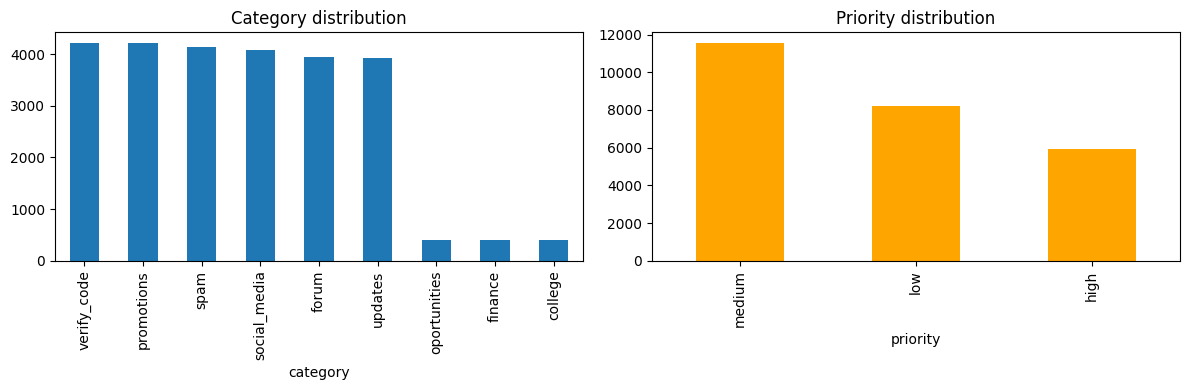

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["category"].value_counts().plot(kind="bar", ax=axes[0], title="Category distribution")
df["priority"].value_counts().plot(kind="bar", ax=axes[1], title="Priority distribution", color="orange")
plt.tight_layout()
plt.show()

In [ ]:
def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"http\S+|www\.\S+", " <url> ", text)
    text = re.sub(r"[^a-z0-9\s<>]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text"] = (df["subject"] + ". " + df["body"]).apply(clean_text)
df[["text", "category", "priority"]].head()

,text,category,priority
0,63 off wireless earbuds this weekend trendify ...,promotions,medium
1,your photography post hit 71 upvotes congrats ...,forum,medium
2,memories from this week in 2021 dear jordan se...,social_media,low
3,temporary pin 321591 for login confirmation en...,verify_code,high
4,labor day blowout 70 off ends monday night sho...,promotions,medium


In [ ]:
hand_labeled_real = [
     {"subject": "Join the meet", "body": "microsoft team link:", "category": "college", "priority": "high"},
     {"subject": "Mess Attendance for the month of July- Regds", "body": "Dear Students,Please see the attached attendance sheet. If you encounter any issues with the attendance sheet, please notify us within two days.Note:1. This email is generated for girls only.2. Please inform us if the students left the hostel, but their names are still marked present in the attendance sheet (only girls' student).", "category": "college", "priority": "high"},
     {"subject": "Amazon Enabling Abilities Program | Registration for Eligible Students", "body": "Dear Student,Greetings from the Training & Placement Cell, IIIT Lucknow.Amazon has invited registrations for Amazon Enabling Abilities, a career readiness program designed to support engineering students with disabilities through skill development, mentorship, networking opportunities, and career preparation.Eligibility:Amazon Enabling Abilities is open to students with disabilities who are currently studying at a university or who have graduated within the last 24 months.Students registered through the program may also be contacted by Amazon regarding relevant internship and full-time opportunities.If you meet the above eligibility criteria and are interested, please register using the link below:", "category": "college", "priority": "high"},
     {"subject": "Regarding Diposal of Waste", "body": "Dear all,This is to inform you that the waste of the garbage dumped near room no 120. Regarding removing this waste from the area a meeting with competent authority is held on 05/08/2026 if anyone has any objection in this regard, please inform us before 08/08/2026. Otherwise the garbage is disposed of from the campus.", "category": "college", "priority": "high"},
     {"subject": "New announcement:No Class today", "body": "No class today", "category": "college", "priority": "medium"},
     {"subject": "Forwarding Advisory for Nasha Mukt Yuva for Viksit Bharat", "body": "Dear Sir/Madam,Please find attached the advisory received from the Ministry of Youth Affairs & Sports regarding the Nasha Mukt Yuva for Viksit Bharat campaign.Kindly share this with all concerned institutions to ensure active participation.", "category": "college", "priority": "medium"},
     {"subject": "MMVY Scholarship Scheme -reg", "body": "All the students who wish to apply for MMVY Scholarship under Renewal category (for Academic Year 2023-24, 2024-25) and for fresh category (for Academic year 2025-26) are hereby requested to do so on the MMVY Portal at the earliest and submit their documents to the scholarship section by 10.08.2026.", "category": "college", "priority": "high"},
     {"subject": "Tentative Timetable for Autumn 2026", "body": "Dear All,Please find the timetable attached here for B. Tech Sem 3, 5 and 7; M.Tech. (DS+AIML) Sem 3, M.Sc. (DS+DS(CLIMATE)+AIML) Sem 3, MBA Sem 3 only. If any changes are required do let me know. Classes start tomorrow", "category": "college", "priority": "high"},
     {"subject": "Syllabus ToA", "body": "This Your syllabus for college studies", "category": "college", "priority": "low"},
     {"subject": "Lost Earbud – Request to Inform if Found", "body": "Dear All,I have unfortunately lost only case  one of my earbuds. I am attaching a photo of the earbud for identification.If anyone finds it, I kindly request you to please inform me or contact me at the earliest. I have also tagged all the branches so that the information can reach everyone who may have found it.Your help in locating my earbud would be greatly appreciated.Thank you for your cooperation.", "category": "college", "priority": "low"},
     {"subject": "Regarding the vacancy of Teaching Volunteer-HEFA-Vidya Samriddhi Initiative", "body": "Dear students,This is to inform you that there is a vacancy of four Teaching volunteers (02 for Mathematics & 02 for Computer Science) for the ongoing project funded by HEFA-Vidya Samriddhi Initiative. The eligibility criteria for the same is as given below. All interested students are requested to send their CV to the Principal Investigator and Co-Investigators of the project (to the email ids given below) by 5 pm, Sunday (2nd August, 2026).The shortlisted candidates will be intimated and called for an interview  next week.", "category": "college", "priority": "high"},
     {"subject": "Hostel Room Allocation for Even Semester 2026", "body": "Dear Students, room allocation for the even semester 2026 has been completed. Please check the student portal for your allotted room number and report to the hostel warden by 10-08-2026 to complete the check-in formalities.", "category": "college", "priority": "high"},
     {"subject": "Library Book Return Reminder", "body": "Dear Student, this is a reminder that you have books due for return by 09-08-2026. Kindly return them to the central library to avoid a late fine of Rs.5 per day per book.", "category": "college", "priority": "medium"},
     {"subject": "Wi-Fi Maintenance Notice - Academic Block", "body": "Dear All, the campus Wi-Fi network in the Academic Block will be down for scheduled maintenance on 08-08-2026 from 10 AM to 2 PM. We regret the inconvenience caused.", "category": "college", "priority": "low"},
     {"subject": "Invitation: Guest Lecture on Quantum Computing", "body": "Dear Students, the Department of CSE is organizing a guest lecture on Quantum Computing by Dr. Anil Kumar on 12-08-2026 at 3 PM in Seminar Hall 1. All interested students are welcome to attend.", "category": "college", "priority": "medium"},
     {"subject": "Internal Assessment 2 Schedule Released", "body": "Dear Students, the schedule for Internal Assessment 2 has been released on the student portal. Please check your respective subject timings and report to the exam hall 15 minutes before the scheduled time.", "category": "college", "priority": "high"},
     {"subject": "Blood Donation Camp - Register Now", "body": "Dear Students, the NSS unit is organizing a blood donation camp on campus on 11-08-2026. Interested and eligible students can register at the NSS office by 09-08-2026.", "category": "college", "priority": "medium"},
     {"subject": "Change in Mess Menu - Feedback Invited", "body": "Dear Students, based on feedback received, the mess menu will be revised starting next week. Please share your suggestions with the mess committee by 08-08-2026.", "category": "college", "priority": "low"},
     {"subject": "Notice: ID Card Renewal for Final Year Students", "body": "Dear Students, final year students are required to renew their college ID cards before the end of this semester. Please visit the administrative office with a passport size photograph.", "category": "college", "priority": "medium"},
     {"subject": "TA/RA Vacancy - Department of Mathematics", "body": "Applications are invited for the post of Teaching Assistant in the Department of Mathematics for the ongoing semester. Interested students may send their CV to the department office by 10-08-2026.", "category": "college", "priority": "high"},
     {"subject": "Cultural Fest Volunteers Required", "body": "Dear Students, the annual cultural fest committee is looking for volunteers for various coordination roles. Interested students can fill the volunteer form available on the college website.", "category": "college", "priority": "medium"},

     {"subject": "Competition Launch: Kaggriculture", "body": "Hi omp4til,Can your AI agent cultivate a winning strategy?Welcome to Kaggriculture, a simulation competition where you build an autonomous AI agent that plants crops, raises animals, and trades in a market that reacts to every player's moves. Then compete head-to-head on a live leaderboard.Winning takes more than a green thumb. It takes careful planning, smart resource management, and a well-tuned agent.", "category": "oportunities", "priority": "high"},
     {"subject": "Adobe University Hackathon 2026 | Registrations Open", "body": "Dear Students,This is a reminder to register for the Adobe University Hackathon 2026 by 8th August 2026 using the following link.", "category": "oportunities", "priority": "high"},
     {"subject": "Amazon Enabling Abilities Program | Registration for Eligible Students", "body": "Dear Student,Greetings from the Training & Placement Cell, IIIT Lucknow.Amazon has invited registrations for Amazon Enabling Abilities, a career readiness program designed to support engineering students with disabilities through skill development, mentorship, networking opportunities, and career preparation.Eligibility:Amazon Enabling Abilities is open to students with disabilities who are currently studying at a university or who have graduated within the last 24 months.Students registered through the program may also be contacted by Amazon regarding relevant internship and full-time opportunities.If you meet the above eligibility criteria and are interested, please register using the link below:", "category": "oportunities", "priority": "high"},
     {"subject": "Guidelines and key Instructions for the Round 1 - Online Assessment (MCQ + Coding)! | Adobe University Hackathon 2026", "body": "The assessment does not get terminated on the first such instance. Only repeated violations will result in disqualification and termination of the assessment immediately..", "category": "oportunities", "priority": "high"},
     {"subject": "We noticed what you did! :)", "body": "Hi Om, you are exploring opportunities on Unstop.That tells us something. You don't just wait, you prepare for them.", "category": "oportunities", "priority": "medium"},
     {"subject": "Your profile is a perfect match for these 'Web Development' internships", "body": "Hi Om,Here are some of the latest opportunities matching your preferences. Apply now!", "category": "oportunities", "priority": "medium"},
     {"subject": "Only 1 Day left: Complete Your Registration for the Adobe University Hackathon 2026!", "body": "You were one click away from putting Adobe on your radar.Don't let an incomplete application be the reason you miss out on an internship opportunity with Adobe.", "category": "oportunities", "priority": "high"},
     {"subject": "New in Render: Do more with your coding agent", "body": "Heads up: we're giving this newsletter a bit of a reset, so you can expect to start hearing from us more regularly about all the good stuff heading your way.We've just shipped several updates that expand what your coding agent can do. You'll also find faster builds, stronger security, and more control over your data.", "category": "oportunities", "priority": "low"},
     {"subject": "Qubixo is hiring Java Development intern and your profile matches", "body": "Dear Students,Here are some of the latest opportunities matching your preferences. Apply now!", "category": "oportunities", "priority": "medium"},
     {"subject": "Update: Join Air India Campus Ambassador Programme | Confirm your spot!", "body": "Register now !! seats are filling very quick it is great opourtunity", "category": "oportunities", "priority": "high"},
     {"subject": "Amrata is hiring Python Development intern | Apply Now", "body": "Here are some of the latest opportunities matching your preferences. Apply now!", "category": "oportunities", "priority": "medium"},
     {"subject": "Congratulations! You Have Successfully Submitted Your First Application On Internshala", "body": "Congratulations on making your first application on Internshala.Let's first get you acquainted with some guidelines to be followed on Internshala -", "category": "oportunities", "priority": "medium"},
     {"subject": "You're shortlisted! Next round for SDE Intern at Zeta Labs", "body": "Hi, congratulations! Based on your application, you have been shortlisted for the next round of the SDE Internship at Zeta Labs. The next round will be a technical interview scheduled for next week.", "category": "oportunities", "priority": "high"},
     {"subject": "LinkedIn: 5 new jobs match your profile", "body": "Hi, based on your profile and skills, we found 5 new job openings that match what you're looking for. Tap to view and apply before the openings close.", "category": "oportunities", "priority": "medium"},
     {"subject": "GSoC 2027 - Applications Opening Soon", "body": "Google Summer of Code 2027 applications will open next month. Start exploring participating organizations and preparing your proposal now to increase your chances of selection.", "category": "oportunities", "priority": "medium"},
     {"subject": "Reminder: Codeforces Round 1023 starts in 2 hours", "body": "Hi, this is a reminder that Codeforces Round 1023 (Div 2) starts in 2 hours. Make sure you're registered and ready to compete.", "category": "oportunities", "priority": "high"},
     {"subject": "Your application for Research Internship has been received", "body": "Dear Applicant, we have received your application for the Summer Research Internship program. Shortlisted candidates will be contacted for an interview by 15-08-2026.", "category": "oportunities", "priority": "medium"},
     {"subject": "Exclusive: Apply for Microsoft Learn Student Ambassador Program", "body": "Hi, the Microsoft Learn Student Ambassador Program is now accepting applications. This is a great opportunity to build technical skills and grow your professional network. Apply before the deadline.", "category": "oportunities", "priority": "high"},
     {"subject": "New internship alert: Data Science Intern at Finlytics", "body": "Hi, a new internship matching your profile has been posted. Finlytics is hiring Data Science Interns. Apply now before the position is filled.", "category": "oportunities", "priority": "medium"},
     {"subject": "You've been invited to a mock interview session", "body": "Hi, based on your recent activity, you have been invited to a free mock interview session hosted by our placement partner. Book your slot now to prepare for upcoming placements.", "category": "oportunities", "priority": "medium"},
     {"subject": "Semester Exchange Program - Applications Open", "body": "Dear Students, applications are now open for the semester exchange program with partner universities abroad. Eligible students can apply through the international relations office before the deadline.", "category": "oportunities", "priority": "high"},

     {"subject": "Rs.1,499.00 debited from your A/c", "body": "Dear Customer, your Bank of Baroda A/c XX4521 has been debited by Rs.1,499.00 on 05-08-2026. UPI Ref No 402215896321. Available balance: Rs.8,214.30. If this transaction was not done by you, please report immediately.", "category": "finance", "priority": "high"},
     {"subject": "Payment of Rs.250.00 to Swiggy successful", "body": "Your UPI payment of Rs.250.00 to Swiggy has been completed successfully. Transaction ID: 402216783452. Thank you for using our services.", "category": "finance", "priority": "medium"},
     {"subject": "Your ICICI Bank Credit Card statement is generated", "body": "Dear Cardholder, your credit card statement for the billing cycle ending 31-07-2026 is now available. Total amount due: Rs.6,420.00. Payment due date: 20-08-2026. Please pay by the due date to avoid late fee charges.", "category": "finance", "priority": "high"},
     {"subject": "Salary credited to your account", "body": "Dear Employee, your salary for the month of July 2026 amounting to Rs.28,500.00 has been credited to your registered bank account. Please check your account for confirmation.", "category": "finance", "priority": "medium"},
     {"subject": "Low balance alert - Savings Account", "body": "Dear Customer, your available balance in A/c XX7742 is Rs.412.50, which is below the minimum required balance. Please deposit funds to avoid penalty charges.", "category": "finance", "priority": "high"},
     {"subject": "Refund of Rs.799.00 credited to your account", "body": "Your refund for the cancelled order #ORD48213 has been processed. Rs.799.00 will be credited to your original payment method within 5-7 business days.", "category": "finance", "priority": "medium"},
     {"subject": "Your SIP installment has been processed", "body": "Dear Investor, your monthly SIP installment of Rs.2,000.00 in HDFC Flexi Cap Fund has been processed successfully. Units allotted: 34.128 at NAV Rs.58.62.", "category": "finance", "priority": "medium"},
     {"subject": "Transaction alert: Rs.2,450.00 spent on your Debit Card", "body": "A transaction of Rs.2,450.00 was made using your Debit Card ending 8823 at Amazon Retail on 06-08-2026, 14:32 IST. If you did not authorize this transaction, please contact us immediately.", "category": "finance", "priority": "high"},
     {"subject": "EMI of Rs.3,200.00 due on 10-08-2026", "body": "Dear Customer, your EMI of Rs.3,200.00 for Personal Loan A/c XX3391 is due on 10-08-2026. Please ensure sufficient balance in your linked account to avoid a bounce charge.", "category": "finance", "priority": "high"},
     {"subject": "Your electricity bill of Rs.1,120.00 is due", "body": "Dear Consumer, your electricity bill of Rs.1,120.00 for the billing period July 2026 is due on 15-08-2026. Pay now to avoid late payment surcharge.", "category": "finance", "priority": "high"},
     {"subject": "Mobile recharge of Rs.239.00 successful", "body": "Your prepaid mobile recharge of Rs.239.00 was successful. Validity extended till 07-09-2026. Thank you for recharging with us.", "category": "finance", "priority": "low"},
     {"subject": "Insurance premium due reminder", "body": "Dear Policyholder, your premium of Rs.4,500.00 for policy no. LIC48213967 is due on 18-08-2026. Please pay before the due date to keep your policy active.", "category": "finance", "priority": "high"},
     {"subject": "Fixed Deposit maturing soon", "body": "Dear Customer, your Fixed Deposit A/c XX5521 of Rs.50,000.00 is maturing on 20-08-2026. Please visit your nearest branch or use net banking to renew or withdraw.", "category": "finance", "priority": "medium"},
     {"subject": "Auto-debit failed for your loan EMI", "body": "Dear Customer, the auto-debit for your EMI of Rs.2,750.00 due on 05-08-2026 has failed due to insufficient balance. Please make the payment manually to avoid penalty charges.", "category": "finance", "priority": "high"},
     {"subject": "Your PF statement is now available", "body": "Dear Member, your Provident Fund passbook has been updated. Total balance as of July 2026: Rs.1,42,300.00. Login to the EPFO portal to view the detailed statement.", "category": "finance", "priority": "low"},
     {"subject": "Cashback of Rs.50.00 credited", "body": "Congratulations! You have received a cashback of Rs.50.00 for your recent UPI transaction. The amount has been credited to your wallet.", "category": "finance", "priority": "low"},
     {"subject": "ITR Filing Reminder - Deadline Approaching", "body": "Dear Taxpayer, the last date to file your Income Tax Return for AY 2026-27 is approaching. File your return before 31-08-2026 to avoid late fee under section 234F.", "category": "finance", "priority": "high"},
     {"subject": "Stipend credited for July 2026", "body": "Dear Intern, your monthly stipend of Rs.8,000.00 for July 2026 has been credited to your registered bank account. Please check your account for confirmation.", "category": "finance", "priority": "medium"},
     {"subject": "Credit score updated", "body": "Dear Customer, your credit score has been updated to 762. Check your full credit report on the app for a detailed breakdown of factors affecting your score.", "category": "finance", "priority": "low"},
     {"subject": "Rs.500.00 added to your Paytm Wallet", "body": "Rs.500.00 has been successfully added to your Paytm Wallet via UPI. Transaction ID: 990215487632. Balance available for use.", "category": "finance", "priority": "low"},
]

In [ ]:
if hand_labeled_real:
    extra_real_df = pd.DataFrame(hand_labeled_real)
    extra_real_df["origin"] = "real"
    extra_real_df["text"] = (extra_real_df["subject"] + ". " + extra_real_df["body"]).apply(clean_text)
    df = pd.concat([df, extra_real_df], ignore_index=True)
    print("Added", len(extra_real_df), "hand-labeled real rows")
    print(extra_real_df[["text", "category", "priority"]].head())
else:
    print("No hand-labeled examples added yet -- college/oportunities stay synthetic-only.")

Added 62 hand-labeled real rows
                                                text category priority
0                  join the meet microsoft team link  college     high
1  mess attendance for the month of july regds de...  college     high
2  amazon enabling abilities program registration...  college     high
3  regarding diposal of waste dear all this is to...  college     high
4     new announcement no class today no class today  college   medium


In [ ]:
real_df = df[df["origin"] == "real"].reset_index(drop=True)
synth_df = df[df["origin"] == "synthetic"].reset_index(drop=True)

MIN_FOR_HOLDOUT = 15

real_train_parts, val_parts, test_parts = [], [], []

for cat, group in real_df.groupby("category"):
    n = len(group)
    if n < MIN_FOR_HOLDOUT:

        real_train_parts.append(group)
        print(f"  {cat}: only {n} real examples -> all sent to train (skipped val/test)")
    else:
        g_train, g_temp = train_test_split(group, test_size=0.3, random_state=SEED)
        g_val, g_test = train_test_split(g_temp, test_size=0.5, random_state=SEED)
        real_train_parts.append(g_train)
        val_parts.append(g_val)
        test_parts.append(g_test)

real_train = pd.concat(real_train_parts, ignore_index=True)

sparse_mask = real_train["category"].isin(SPARSE_REAL_CATEGORIES)
real_train_sparse = pd.concat([real_train[sparse_mask]] * REAL_OVERSAMPLE_FACTOR, ignore_index=True)
real_train = pd.concat([real_train[~sparse_mask], real_train_sparse], ignore_index=True)
print("real_train after oversampling sparse categories:", len(real_train))
print(real_train[real_train["category"].isin(SPARSE_REAL_CATEGORIES)]["category"].value_counts())
val_df = pd.concat(val_parts, ignore_index=True) if val_parts else pd.DataFrame(columns=real_df.columns)
test_df = pd.concat(test_parts, ignore_index=True) if test_parts else pd.DataFrame(columns=real_df.columns)

train_df = pd.concat([real_train, synth_df], ignore_index=True)
train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"\ntrain: {len(train_df)} (real: {len(real_train)}, synthetic: {len(synth_df)})")
print(f"val: {len(val_df)}  (100% real)")
print(f"test: {len(test_df)}  (100% real)")

no_holdout = set(real_df["category"].unique()) - set(val_df["category"].unique() if len(val_df) else [])
if no_holdout:
    print(f"\nNo held-out real examples yet for: {no_holdout}")
    print("-> collect a few more real emails for these before trusting their metrics.")

real_train after oversampling sparse categories: 9066
category
college         112
finance         112
oportunities    112
Name: count, dtype: int64

train: 22266 (real: 9066, synthetic: 13200)
val: 1881  (100% real)
test: 1885  (100% real)


In [ ]:
def tokenize(text: str):
    return text.split()

word_counts = Counter()
for text in train_df["text"]:
    word_counts.update(tokenize(text))

real_train_words = set()
for text in train_df.loc[train_df["origin"] == "real", "text"]:
    real_train_words.update(tokenize(text))

frequent_words = {w for w, c in word_counts.items() if c >= MIN_WORD_FREQ}
vocab = ["<PAD>", "<UNK>"] + sorted(frequent_words | real_train_words)
word2idx = {w: i for i, w in enumerate(vocab)}
VOCAB_SIZE = len(vocab)
print("Vocab size:", VOCAB_SIZE)

Vocab size: 10352


In [ ]:

sample_text = train_df.loc[train_df["category"] == "oportunities", "text"].iloc[0]
toks = tokenize(sample_text)
unk_ratio = sum(1 for t in toks if t not in word2idx) / max(len(toks), 1)
print("sample:", sample_text[:120])
print(f"tokens: {len(toks)}  |  unk ratio: {unk_ratio:.1%}")
print("(should be well under 30% now -- if still high, the fix above needs another look)")

sample: project collaboration request home renovation forwarded message from salesman3407 example com date mon jun 5 subject pro
tokens: 40  |  unk ratio: 5.0%
(should be well under 30% now -- if still high, the fix above needs another look)


In [ ]:
PAD_IDX = word2idx["<PAD>"]
UNK_IDX = word2idx["<UNK>"]

def encode(text: str, max_len: int = MAX_LEN):
    tokens = tokenize(text)[:max_len]
    ids = [word2idx.get(t, UNK_IDX) for t in tokens]
    ids = ids + [PAD_IDX] * (max_len - len(ids))
    return ids

cat2idx = {c: i for i, c in enumerate(CATEGORIES)}
pri2idx = {p: i for i, p in enumerate(PRIORITIES)}

In [ ]:
class EmailDataset(Dataset):
    def __init__(self, dataframe):
        self.texts = dataframe["text"].tolist()
        self.categories = dataframe["category"].tolist()
        self.priorities = dataframe["priority"].tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = encode(self.texts[idx])
        return {
            "input_ids": torch.tensor(ids, dtype=torch.long),
            "category": torch.tensor(cat2idx[self.categories[idx]], dtype=torch.long),
            "priority": torch.tensor(pri2idx[self.priorities[idx]], dtype=torch.long),
        }

train_ds = EmailDataset(train_df)
val_ds = EmailDataset(val_df)
test_ds = EmailDataset(test_df)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

print("Batches -> train:", len(train_loader), "val:", len(val_loader), "test:", len(test_loader))

Batches -> train: 696 val: 59 test: 59


In [ ]:
class BiGRUMultiTaskClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_categories, num_priorities,
                 num_layers=1, dropout=0.3, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.category_head = nn.Linear(hidden_dim * 2, num_categories)
        self.priority_head = nn.Linear(hidden_dim * 2, num_priorities)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)
        outputs, hidden = self.gru(embedded)
        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]
        combined = torch.cat([forward_hidden, backward_hidden], dim=1)
        combined = self.dropout(combined)
        category_logits = self.category_head(combined)
        priority_logits = self.priority_head(combined)
        return category_logits, priority_logits

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BiGRUMultiTaskClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_categories=len(CATEGORIES),
    num_priorities=len(PRIORITIES),
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    pad_idx=PAD_IDX,
).to(device)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {num_params:,}")
model

Trainable parameters: 1,526,284


BiGRUMultiTaskClassifier(
  (embedding): Embedding(10352, 128, padding_idx=0)
  (gru): GRU(128, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (category_head): Linear(in_features=256, out_features=9, bias=True)
  (priority_head): Linear(in_features=256, out_features=3, bias=True)
)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

In [ ]:
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    cat_preds, cat_true = [], []
    pri_preds, pri_true = [], []

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            category = batch["category"].to(device)
            priority = batch["priority"].to(device)

            if is_train:
                optimizer.zero_grad()

            category_logits, priority_logits = model(input_ids)
            loss = criterion(category_logits, category) + criterion(priority_logits, priority)

            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()
            total_loss += loss.item() * input_ids.size(0)
            cat_preds.extend(category_logits.argmax(dim=1).cpu().tolist())
            cat_true.extend(category.cpu().tolist())
            pri_preds.extend(priority_logits.argmax(dim=1).cpu().tolist())
            pri_true.extend(priority.cpu().tolist())

    avg_loss = total_loss / len(loader.dataset)
    cat_acc = accuracy_score(cat_true, cat_preds)
    pri_acc = accuracy_score(pri_true, pri_preds)
    return avg_loss, cat_acc, pri_acc

In [ ]:
best_val_loss = float("inf")
patience, patience_counter = 3, 0
history = {"train_loss": [], "val_loss": [], "val_cat_acc": [], "val_pri_acc": []}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_cat_acc, train_pri_acc = run_epoch(model, train_loader, optimizer)
    val_loss, val_cat_acc, val_pri_acc = run_epoch(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_cat_acc"].append(val_cat_acc)
    history["val_pri_acc"].append(val_pri_acc)

    print(f"epoch {epoch:2d}/{EPOCHS} | train_loss {train_loss:.4f} | "
          f"val_loss {val_loss:.4f} | val_cat_acc {val_cat_acc:.3f} | val_pri_acc {val_pri_acc:.3f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), f"{ARTIFACT_DIR}/bigru_model.pt")
        print(f"  -> new best model saved (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"  -> early stopping at epoch {epoch} (no val_loss improvement for {patience} epochs)")
            break

print("Best validation loss:", best_val_loss)

epoch  1/20 | train_loss 0.4436 | val_loss 0.2925 | val_cat_acc 0.961 | val_pri_acc 0.961
  -> new best model saved (val_loss=0.2925)
epoch  2/20 | train_loss 0.0614 | val_loss 0.3160 | val_cat_acc 0.969 | val_pri_acc 0.963
epoch  3/20 | train_loss 0.0310 | val_loss 0.2557 | val_cat_acc 0.971 | val_pri_acc 0.969
  -> new best model saved (val_loss=0.2557)
epoch  4/20 | train_loss 0.0192 | val_loss 0.3185 | val_cat_acc 0.974 | val_pri_acc 0.967
epoch  5/20 | train_loss 0.0185 | val_loss 0.2365 | val_cat_acc 0.976 | val_pri_acc 0.974
  -> new best model saved (val_loss=0.2365)
epoch  6/20 | train_loss 0.0167 | val_loss 0.2265 | val_cat_acc 0.978 | val_pri_acc 0.971
  -> new best model saved (val_loss=0.2265)
epoch  7/20 | train_loss 0.0104 | val_loss 0.2849 | val_cat_acc 0.972 | val_pri_acc 0.968
epoch  8/20 | train_loss 0.0141 | val_loss 0.4427 | val_cat_acc 0.969 | val_pri_acc 0.959
epoch  9/20 | train_loss 0.0097 | val_loss 0.3076 | val_cat_acc 0.974 | val_pri_acc 0.965
  -> early sto

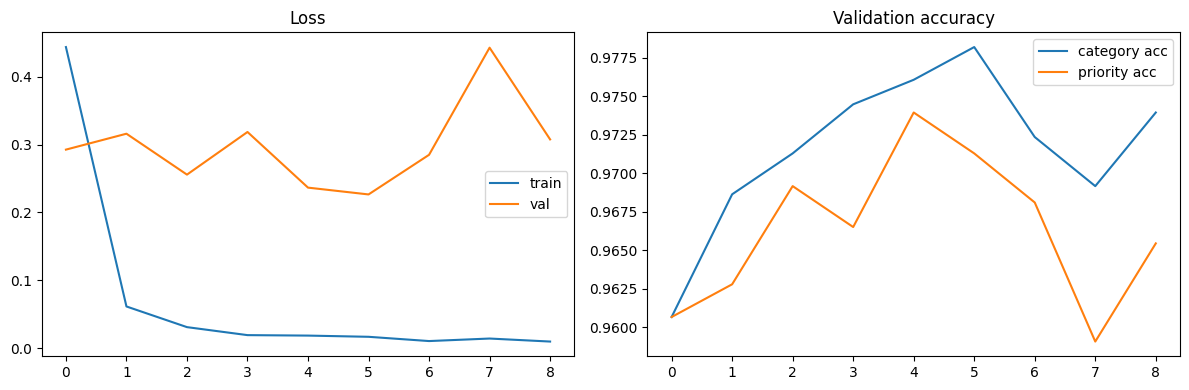

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(history["val_cat_acc"], label="category acc")
axes[1].plot(history["val_pri_acc"], label="priority acc")
axes[1].set_title("Validation accuracy"); axes[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
import optuna

def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    hidden_dim = trial.suggest_categorical("hidden_dim", [64, 128, 256])
    dropout = trial.suggest_float("dropout", 0.1, 0.5)

    trial_model = BiGRUMultiTaskClassifier(
        vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, hidden_dim=hidden_dim,
        num_categories=len(CATEGORIES), num_priorities=len(PRIORITIES),
        num_layers=NUM_LAYERS, dropout=dropout, pad_idx=PAD_IDX,
    ).to(device)
    trial_optimizer = torch.optim.Adam(trial_model.parameters(), lr=lr)

    for _ in range(3):
        run_epoch(trial_model, train_loader, trial_optimizer)
    _, val_cat_acc, _ = run_epoch(trial_model, val_loader)
    return val_cat_acc

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=8)

print("Best hyperparameters:", study.best_params)
print("Best val category accuracy:", study.best_value)


[I 2026-08-10 05:52:28,495] A new study created in memory with name: no-name-ffccd50c-a139-4354-98a0-bb73a707e193
[I 2026-08-10 05:53:04,314] Trial 0 finished with value: 0.9750132908027644 and parameters: {'lr': 0.0026278967669869724, 'hidden_dim': 256, 'dropout': 0.3533234113704534}. Best is trial 0 with value: 0.9750132908027644.
[I 2026-08-10 05:53:22,576] Trial 1 finished with value: 0.9718234981392876 and parameters: {'lr': 0.001227819657010298, 'hidden_dim': 128, 'dropout': 0.34140833182913355}. Best is trial 0 with value: 0.9750132908027644.
[I 2026-08-10 05:53:35,192] Trial 2 finished with value: 0.9712918660287081 and parameters: {'lr': 0.0011992380159538006, 'hidden_dim': 128, 'dropout': 0.22589504176077235}. Best is trial 0 with value: 0.9750132908027644.
[I 2026-08-10 05:53:47,893] Trial 3 finished with value: 0.9654439128123339 and parameters: {'lr': 0.00047975882023915876, 'hidden_dim': 128, 'dropout': 0.3179304645211519}. Best is trial 0 with value: 0.9750132908027644.


Best hyperparameters: {'lr': 0.0026278967669869724, 'hidden_dim': 256, 'dropout': 0.3533234113704534}
Best val category accuracy: 0.9750132908027644


In [ ]:
model.load_state_dict(torch.load(f"{ARTIFACT_DIR}/bigru_model.pt", map_location=device))
model.eval()

all_cat_preds, all_cat_true = [], []
all_pri_preds, all_pri_true = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        category_logits, priority_logits = model(input_ids)
        all_cat_preds.extend(category_logits.argmax(dim=1).cpu().tolist())
        all_cat_true.extend(batch["category"].tolist())
        all_pri_preds.extend(priority_logits.argmax(dim=1).cpu().tolist())
        all_pri_true.extend(batch["priority"].tolist())

print("=== Category classification report ===")
print(classification_report(all_cat_true, all_cat_preds, target_names=CATEGORIES, labels=list(range(len(CATEGORIES))), zero_division=0))

print("=== Priority classification report ===")
print(classification_report(all_pri_true, all_pri_preds, target_names=PRIORITIES, labels=list(range(len(PRIORITIES)))))


=== Category classification report ===
              precision    recall  f1-score   support

       forum       0.98      0.99      0.98       291
  promotions       1.00      0.98      0.99       331
social_media       0.99      0.97      0.98       312
        spam       0.99      0.98      0.98       320
     updates       0.97      1.00      0.98       288
 verify_code       0.98      0.99      0.99       332
oportunities       0.33      0.25      0.29         4
     finance       0.33      1.00      0.50         3
     college       1.00      0.25      0.40         4

    accuracy                           0.98      1885
   macro avg       0.84      0.82      0.79      1885
weighted avg       0.98      0.98      0.98      1885

=== Priority classification report ===
              precision    recall  f1-score   support

        high       0.90      0.99      0.95       425
      medium       0.99      0.96      0.98       827
         low       0.99      0.97      0.98       633


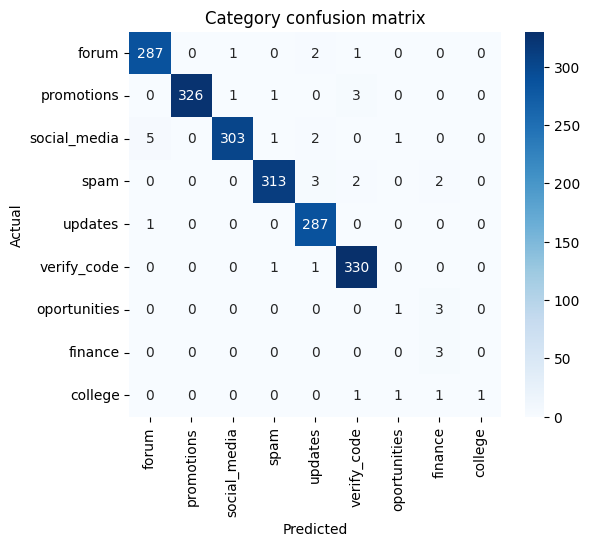

In [ ]:
cm = confusion_matrix(all_cat_true, all_cat_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=CATEGORIES, yticklabels=CATEGORIES, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Category confusion matrix")
plt.show()

In [ ]:
def predict_email_detailed(subject, body):
    model.eval()
    text = clean_text(subject + ". " + body)
    input_ids = encode(text)
    input_tensor = torch.tensor(input_ids, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        category_logits, priority_logits = model(input_tensor)

    predicted_category_idx = category_logits.argmax(dim=1).item()
    predicted_priority_idx = priority_logits.argmax(dim=1).item()

    predicted_category = CATEGORIES[predicted_category_idx]
    predicted_priority = PRIORITIES[predicted_priority_idx]

    print(f"Predicted Category: {predicted_category}")
    print(f"Predicted Priority: {predicted_priority}")

my_subject = "Congratulations! You Have Successfully Submitted Your First Application On Internshala"
my_body = "Congratulations on making your first application on Internshala.Let's first get you acquainted with some guidelines to be followed on Internshala -"

predict_email_detailed(my_subject, my_body)

Predicted Category: oportunities
Predicted Priority: high


In [ ]:
with open(f"{ARTIFACT_DIR}/vocab.pkl", "wb") as f:
    pickle.dump(word2idx, f)

model_config = {
    "vocab_size": VOCAB_SIZE,
    "embed_dim": EMBED_DIM,
    "hidden_dim": HIDDEN_DIM,
    "num_layers": NUM_LAYERS,
    "dropout": DROPOUT,
    "max_len": MAX_LEN,
    "pad_idx": PAD_IDX,
    "categories": CATEGORIES,
    "priorities": PRIORITIES,
}
with open(f"{ARTIFACT_DIR}/model_config.pkl", "wb") as f:
    pickle.dump(model_config, f)

print("Saved to", ARTIFACT_DIR, ":")
print(" - bigru_model.pt   (model weights, PyTorch's native format)")
print(" - vocab.pkl        (word -> index mapping)")
print(" - model_config.pkl (architecture + label config, needed to rebuild the model)")

Saved to artifacts :
 - bigru_model.pt   (model weights, PyTorch's native format)
 - vocab.pkl        (word -> index mapping)
 - model_config.pkl (architecture + label config, needed to rebuild the model)


In [ ]:
with open(f"{ARTIFACT_DIR}/vocab.pkl", "rb") as f:
    loaded_vocab = pickle.load(f)
with open(f"{ARTIFACT_DIR}/model_config.pkl", "rb") as f:
    loaded_config = pickle.load(f)

reloaded_model = BiGRUMultiTaskClassifier(
    vocab_size=loaded_config["vocab_size"],
    embed_dim=loaded_config["embed_dim"],
    hidden_dim=loaded_config["hidden_dim"],
    num_categories=len(loaded_config["categories"]),
    num_priorities=len(loaded_config["priorities"]),
    num_layers=loaded_config["num_layers"],
    dropout=loaded_config["dropout"],
    pad_idx=loaded_config["pad_idx"],
).to(device)
reloaded_model.load_state_dict(torch.load(f"{ARTIFACT_DIR}/bigru_model.pt", map_location=device))
reloaded_model.eval()

def predict_email(subject: str, body: str):
    text = clean_text(subject + ". " + body)
    ids = encode(text, max_len=loaded_config["max_len"])
    input_ids = torch.tensor([ids], dtype=torch.long).to(device)
    with torch.no_grad():
        cat_logits, pri_logits = reloaded_model(input_ids)
    category = loaded_config["categories"][cat_logits.argmax(dim=1).item()]
    priority = loaded_config["priorities"][pri_logits.argmax(dim=1).item()]
    return category, priority

sample_category, sample_priority = predict_email(
    "Interview scheduled tomorrow",
    "Your technical interview is scheduled at 11 AM. Please be on time."
)
print("Predicted category:", sample_category)
print("Predicted priority:", sample_priority)

Predicted category: updates
Predicted priority: medium


In [ ]:
import shutil
from google.colab import files

zip_path = shutil.make_archive("inboxiq_artifacts", "zip", ARTIFACT_DIR)
files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>